# Few-shot Prediction of Perturbation Effects

In this tutorial, we will learn a universal embedding of perturbations and use it for few-shot prediction of perturbtion effects in a new cellular context.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc

import torch

from scmg.model.contrastive_embedding import CellEmbedder, embed_adata
from scmg.model.perturbation_prediction import TrainConfig, train_model, plot_history, get_category_embeddings

Load the trained SCMG model.

In [2]:
# Load the autoencoder model
model_path = 'models/embedder'

scmg_model = torch.load(os.path.join(model_path, 'model.pt'),
                        map_location=torch.device('cpu'))
scmg_model.load_state_dict(torch.load(os.path.join(model_path, 'best_state_dict.pth'),
                    map_location=torch.device('cpu')))

device = 'cpu'
scmg_model.to(device)
scmg_model.eval()

CellEmbedder(
  (encoder): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=18108, out_features=2048, bias=True)
      (1): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
      (2): LeakyReLU(negative_slope=0.01)
      (3): Dropout(p=0.0, inplace=False)
      (4): Linear(in_features=2048, out_features=2048, bias=True)
      (5): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
      (6): LeakyReLU(negative_slope=0.01)
      (7): Dropout(p=0.0, inplace=False)
      (8): Linear(in_features=2048, out_features=512, bias=True)
    )
  )
  (decoder): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=576, out_features=1024, bias=True)
      (1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (2): LeakyReLU(negative_slope=0.01)
      (3): Dropout(p=0, inplace=False)
      (4): Linear(in_features=1024, out_features=2048, bias=True)
      (5): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
      (6): LeakyReLU(negative_slope=0.01)
      

Load the example perturbation dataset.

In [3]:
adata_pert = sc.read_h5ad('data/pseudo_bulk_perturbation_database.h5ad')

# Mask out the direct target genes
for i in range(adata_pert.shape[0]):
    pg = adata_pert.obs['perturbed_gene'].iloc[i]
    
    if pg in adata_pert.var_names:
        adata_pert.X[i, adata_pert.var_names.get_loc(pg)] = 0

## Learn a universal embedding of perturbations

Let's train a universal embedding of perturbations from multiple CRISPRi datasets. We will leave out the dataset for RPE1 cells from the training and use it to test few-shot prediction.

In [4]:
adata_train = adata_pert[adata_pert.obs['condition'].isin([
    'ReplogleWeissman2022_K562_gwps', 'ReplogleWeissman2022_K562_essential', 
    'JiangSatija2024_IFNB', 'JiangSatija2024_TNFA', 'JiangSatija2024_TGFB', 'JiangSatija2024_IFNG', 'JiangSatija2024_INS',
    'FrangiehIzar2021_RNA', 'TianKampmann2021_CRISPRi', 'AdamsonWeissman2016_GSM2406681_10X010',
])].copy()

adata_rpe1 = adata_pert[adata_pert.obs['condition'].isin([
    'ReplogleWeissman2022_rpe1',
])].copy()

Because perturbation effects depend on the starting cell states. We need to provide the cell state information to the model such that it can decompose the intrinsic properties of perturbations from the context-specific effects. We will use the SCMG embedding of the unperturbed cell states to define the cellular context.

In [5]:
adata_pert_ctl = adata_train.copy()
adata_pert_ctl.X = np.exp(adata_train.layers['control']) - 1
embed_adata(scmg_model, adata_pert_ctl, batch_size=8192)

adata_train.obsm['X_ctl_ce_latent'] = adata_pert_ctl.obsm['X_ce_latent']
adata_train

  0%|          | 0/2 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 9541 × 18108
    obs: 'condition', 'perturbed_gene', 'perturbation_sign', 'perturbed_gene_name', 'dataset'
    var: 'gene_name'
    obsm: 'X_ctl_ce_latent'
    layers: 'control', 'measure_mask'

Now we can train a mixture-of-expert model to learn a universal embedding of perturbations

In [6]:
cfg = TrainConfig(epochs=100, batch_size=256, lr=1e-2)

cats = list(adata_train.obs['perturbed_gene_name'].values)
X = adata_train.obsm['X_ctl_ce_latent'].copy()
Y = adata_train.X.copy()
Y_mask = adata_train.layers['measure_mask'].copy()

result = train_model(cats, X, Y, Y_mask, config=cfg, emb_dim=16)

/home/xingjie/Softwares/conda/anaconda3/envs/scmg/lib/python3.10/site-packages/torch/cuda/__init__.py:118: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


Epoch 01 | train_loss=0.0012 | train_corr=0.0485 | 
Epoch 02 | train_loss=0.0011 | train_corr=0.1642 | 
Epoch 03 | train_loss=0.0010 | train_corr=0.2042 | 
Epoch 04 | train_loss=0.0010 | train_corr=0.2392 | 
Epoch 05 | train_loss=0.0009 | train_corr=0.2657 | 
Epoch 06 | train_loss=0.0009 | train_corr=0.2867 | 
Epoch 07 | train_loss=0.0009 | train_corr=0.3058 | 
Epoch 08 | train_loss=0.0009 | train_corr=0.3159 | 
Epoch 09 | train_loss=0.0009 | train_corr=0.3317 | 
Epoch 10 | train_loss=0.0009 | train_corr=0.3398 | 
Epoch 11 | train_loss=0.0009 | train_corr=0.3509 | 
Epoch 12 | train_loss=0.0009 | train_corr=0.3590 | 
Epoch 13 | train_loss=0.0009 | train_corr=0.3672 | 
Epoch 14 | train_loss=0.0009 | train_corr=0.3747 | 
Epoch 15 | train_loss=0.0009 | train_corr=0.3773 | 
Epoch 16 | train_loss=0.0009 | train_corr=0.3836 | 
Epoch 17 | train_loss=0.0009 | train_corr=0.3883 | 
Epoch 18 | train_loss=0.0009 | train_corr=0.3907 | 
Epoch 19 | train_loss=0.0009 | train_corr=0.3938 | 
Epoch 20 | t

We can plot the training loss and the correlation between the predicted and measured perturbation effect vectors as functions of the epochs.

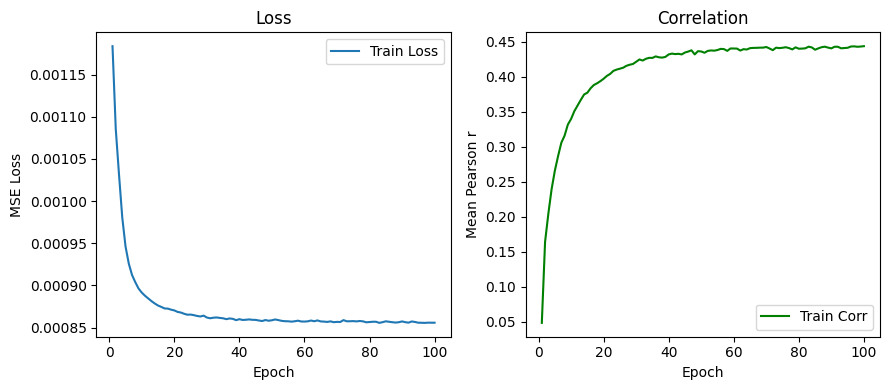

In [7]:
plot_history(result['history'])

The loss function is converged after the training.

Let's extract the perturbation embeddings from the model.

In [8]:
pert_emb_df = get_category_embeddings(result["model"], result["vocab"])

## Few shot prediction
Now we can use the learnt universal perturbation embeddings to perform few-shot prediction for RPE1 cells.

In [9]:
# Assign the perturbation emebdings to the RPE1 dataset
adata_rpe1 = adata_rpe1[adata_rpe1.obs['perturbed_gene_name'].isin(pert_emb_df.index)].copy()
adata_rpe1.obsm['pert_emb'] = pert_emb_df.loc[adata_rpe1.obs['perturbed_gene_name']].values

Let's define simple functions for few-shot prediction

In [10]:
import scipy
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge

def kmeans_find_centroid_indices(X, k):
    '''Use KMeans to find k centroids in the dataset'''
    kmeans = KMeans(n_clusters=k, random_state=0).fit(X)
    centroids = kmeans.cluster_centers_
    indices = []
    for centroid in centroids:
        distances = np.linalg.norm(X - centroid, axis=1)
        index = np.argmin(distances)
        indices.append(index)
    return np.unique(indices)

def few_shot_prediction(adata_ref, adata_query, alpha=3):
    '''Few-shot prediction using Ridge regression'''
    model = Ridge(alpha=alpha)
    model.fit(adata_ref.obsm['pert_emb'], adata_ref.X)
    adata_query.layers['predicted_X'] = model.predict(adata_query.obsm['pert_emb'])

def sim_func(v1, v2):
        return 1 - scipy.spatial.distance.correlation(v1, v2)

As a baseline for comparison, we assume the perturbation effects are context-independent, such that the perturbation effects in RPE1 cells are the same as those in K562 cells.

In [11]:
adata_target = adata_rpe1.copy()

# Create a dictionary to store the prediction accuracy
comp_dict = {
        'k' : [],
        'gene_name' : [],
        'sim': [],
        'true_effect_size' : [],
    }

# Use the K562 dataset as the baseline reference dataset
adata_k562 = adata_pert[adata_pert.obs['condition'].isin([
    'ReplogleWeissman2022_K562_gwps',
])].copy()

# Iterate over each cell in the RPE1 dataset
for i in range(adata_rpe1.shape[0]):
    pg = adata_rpe1.obs['perturbed_gene'].iloc[i]
    
    # Find the corresponding cell in the K562 dataset
    if pg in adata_k562.obs['perturbed_gene'].values:
        v1 = adata_rpe1.X[i]
        j = list(adata_k562.obs['perturbed_gene']).index(pg)
        v2 = adata_k562.X[j]

        comp_dict['k'].append(0)
        comp_dict['gene_name'].append(adata_rpe1.obs['perturbed_gene'].iloc[i])

        # Compute the similarity between the perturbation effect vectors
        comp_dict['sim'].append(sim_func(v1, v2))
        comp_dict['true_effect_size'].append(np.linalg.norm(v1))

Now perform the few-shot prediction using different numbers (K) of few-shot samples as training datasets.

In [12]:
k_values = [5, 10, 20, 50, 100, 200,]

for k in tqdm(k_values):

    # Select k centroids from the RPE1 dataset
    few_shot_ids = kmeans_find_centroid_indices(adata_target.obsm['pert_emb'], k)
    
    # Split the RPE1 dataset into a reference and query set
    adata_ref = adata_target[few_shot_ids, :].copy()
    adata_query = adata_target[~adata_target.obs.index.isin(adata_ref.obs.index)].copy()
    adata_true = adata_target[~adata_target.obs.index.isin(adata_ref.obs.index)].copy()

    # Perform few-shot prediction
    few_shot_prediction(adata_ref, adata_query)

    # Compare the true and predicted perturbation effect vectors
    for i in range(adata_true.shape[0]):
        comp_dict['k'].append(k)
        comp_dict['gene_name'].append(adata_true.obs['perturbed_gene'].iloc[i])

        v1 = adata_true.X[i, :]
        v2 = adata_query.layers['predicted_X'][i, :]

        comp_dict['sim'].append(sim_func(v1, v2))
        comp_dict['true_effect_size'].append(np.linalg.norm(v1))

# Convert the comparison dictionary to a pandas DataFrame
comp_df = pd.DataFrame(comp_dict)

100%|██████████| 6/6 [00:06<00:00,  1.03s/it]


Compare the performance of the baseline and the few-shot prediction results.

/tmp/ipykernel_756038/2975183287.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['baseline \nfrom K562'] + k_values, fontsize=12)


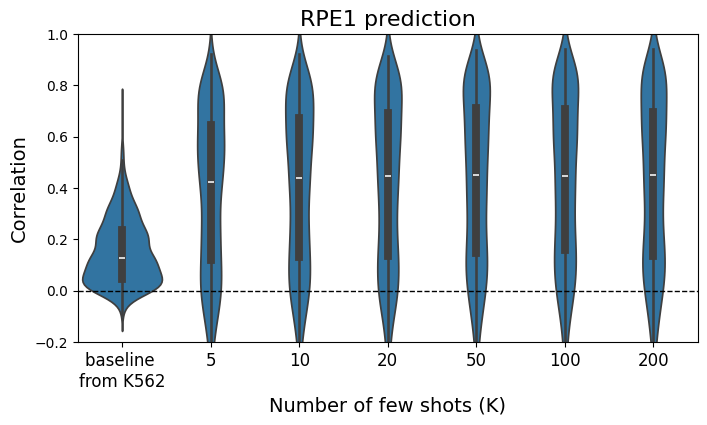

In [13]:
show_df = comp_df.copy()

fig, ax = plt.subplots(figsize=(8,4))
sns.violinplot(data=show_df, x='k', y='sim',
               order=[0] +k_values, 
               #inner= 'quart', fill=False, #color='tab:green',
               width=0.9,
               ax=ax, )

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylim(-0.2, 1.0)
ax.set_xlabel('Number of few shots (K)', fontsize=14)
ax.set_ylabel('Correlation', fontsize=14)
ax.set_title('RPE1 prediction', fontsize=16)

ax.set_xticklabels(['baseline \nfrom K562'] + k_values, fontsize=12)
plt.show()

The few-shot predictor outperforms the baseline even when only K=5 samples are used for few-shot training.

For a given K, we can futher investigate how the prediction accuracy depends on the perturbation effect size. 

Text(0.5, 1.0, 'RPE1 prediction')

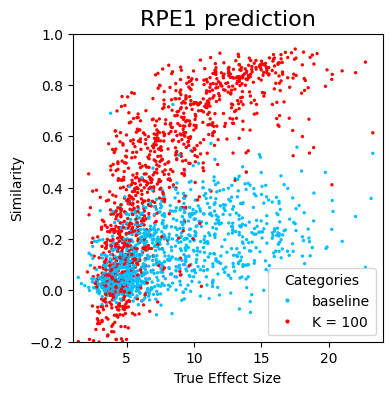

In [14]:
k1 = 0
k2 = 100
show_df = comp_df[
     (comp_df['k'].isin([k1, k2]))
].copy()
show_df['color'] = 'deepskyblue'
show_df.loc[show_df['k'] == k2, 'color'] = 'red'
shuffled_df = show_df.sample(frac=1, random_state=42, replace=False)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(shuffled_df['true_effect_size'], shuffled_df['sim'], s=2, alpha=1, rasterized=True, color=shuffled_df['color'])

ax.set_xlim(1, 24)
ax.set_ylim(-0.2, 1)

# Add legend to the plot
handles = []
handles.append(plt.Line2D([0], [0], marker='o', linestyle='', color='deepskyblue', markersize=2))
handles.append(plt.Line2D([0], [0], marker='o', linestyle='', color='red', markersize=2))
plt.legend(handles=handles, labels=[f'baseline', f'K = {k2}'], title='Categories')

ax.set_xlabel('True Effect Size')
ax.set_ylabel('Similarity')
ax.set_title('RPE1 prediction', fontsize=16)

We can see a strong dependency of the prediction accuracy on the perturbation effect size, suggesting that the low accuracy predictions may be partially due to low signal-to-noise ratios for perturbations with small effects.